FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/contour_3d.png'

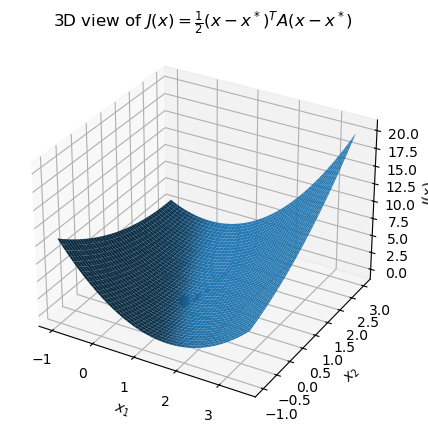

In [6]:
# Python script: create 3D surface + contour/top view of a quadratic objective
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Quadratic: J(x) = 0.5 * (x - x_star)^T A (x - x_star)
A = np.array([[3.0, 1.2],
              [1.2, 1.0]])
x_star = np.array([1.0, 0.5])

def J(xy):
    v = xy - x_star
    return 0.5 * v @ (A @ v)

def grad_J(xy):
    return A @ (xy - x_star)

# Grid for plotting
x = np.linspace(-1.0, 3.5, 200)
y = np.linspace(-1.0, 3.0, 180)
X, Y = np.meshgrid(x, y)
Z = np.vectorize(lambda xx, yy: J(np.array([xx, yy])))(X, Y)

# Choose a point x^(0) for illustrating gradient/tangent
x0 = np.array([2.4, 1.2])
g0 = grad_J(x0)
t0 = np.array([-g0[1], g0[0]])
t0 = t0 / np.linalg.norm(t0)

# Plot 1: 3D surface
fig1 = plt.figure(figsize=(7, 5))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.plot_surface(X, Y, Z, linewidth=0, antialiased=True)
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$J(x)$')
ax1.set_title('3D view of $J(x)=\\frac{1}{2}(x-x^*)^T A (x-x^*)$')
ax1.scatter([x_star[0]], [x_star[1]], [J(x_star)], marker='o', s=50)
ax1.text(x_star[0], x_star[1], J(x_star), '  $x^*$', fontsize=10)
fig1_path = '/mnt/data/contour_3d.png'
fig1.savefig(fig1_path, dpi=150, bbox_inches='tight')

# Plot 2: Contour (top view) with gradient and tangent
fig2, ax2 = plt.subplots(figsize=(7, 6))
levels = np.logspace(-3, 1.5, 12)
CS = ax2.contour(X, Y, Z, levels=levels)
ax2.clabel(CS, inline=True, fontsize=8)

ax2.scatter([x_star[0]], [x_star[1]], marker='o', s=40)
ax2.annotate('$x^*$', (x_star[0], x_star[1]), textcoords="offset points", xytext=(5,5))

ax2.scatter([x0[0]], [x0[1]], marker='o', s=40)
ax2.annotate('$x^{(0)}$', (x0[0], x0[1]), textcoords="offset points", xytext=(5,5))

# gradient arrow and tangent line
scale = 0.35
ax2.quiver(x0[0], x0[1], g0[0]*scale, g0[1]*scale, angles='xy', scale_units='xy', scale=1)
tlen = 1.5
pts = np.vstack([x0 - tlen*t0, x0 + tlen*t0])
ax2.plot(pts[:,0], pts[:,1], linestyle='--')

# illustrative next iterate
x1 = x0 - 0.6 * g0
ax2.scatter([x1[0]], [x1[1]], marker='o', s=40)
ax2.annotate('$x^{(1)}$', (x1[0], x1[1]), textcoords="offset points", xytext=(5,5))

ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.set_title('Contour view (top) with gradient and tangent at $x^{(0)}$')
ax2.set_aspect('equal', 'box')
ax2.grid(True)
fig2_path = '/mnt/data/contour_top.png'
fig2.savefig(fig2_path, dpi=150, bbox_inches='tight')

plt.show()
